In [47]:

import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px

In [48]:
df = pd.read_csv("../data/papers.csv")
total_papers = len(df)
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Link to Data', 'Data Details', 'Size',
       'Number of Prompts', 'Medical Application', 'Task Type', 'Topic',
       'Note', 'Bias Evaluation Metric', 'Bias Definition', 'Conclusions',
       'Race / Ethnic Bias', 'Language Bias', 'Age Bias', 'Gender Bias',
       'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Geography / Cultural Bias', 'Evaluated LLMs',
       'Reference Standard \n(Human / Model / System / Physician)',
       'Patient Inclusion\n(Yes / No)', 'Has Debiasing',
       'Debias - Focus\n(Data/Train/Inference)', 'Debias-details'],
      dtype='str')

In [49]:
paper_conclusions_lst = df["Conclusions"].tolist()
conclusions_mps = {}

for paper in paper_conclusions_lst:
    if isinstance(paper, float):
        continue

    # comma-separated list like: "Female: Yes (...), Male: No (...)"
    for conclusion in str(paper).split(","):
        try:
            # drop parenthetical notes
            value = re.sub(r"\s*\([^)]*\)", "", conclusion).strip()

            key, val = (part.strip() for part in value.split(":", 1))
            if not key or not val:
                continue

            key_norm = key.strip()
            yn = val.strip().lower().split(None, 1)[0]  # first token

            if key_norm not in conclusions_mps:
                conclusions_mps[key_norm] = {"yes": 0, "no": 0}

            if yn == "yes":
                conclusions_mps[key_norm]["yes"] += 1
            elif yn == "no":
                conclusions_mps[key_norm]["no"] += 1

        except ValueError:
            continue

conclusions_mps

{'Female': {'yes': 14, 'no': 15},
 'Male': {'yes': 8, 'no': 20},
 'White': {'yes': 5, 'no': 15},
 'Non White': {'yes': 0, 'no': 1},
 'African American': {'yes': 2, 'no': 2},
 'Caucasion': {'yes': 1, 'no': 0},
 'Ashkenazi Jews': {'yes': 1, 'no': 0},
 'Mediterranean/Middle Eastern': {'yes': 1, 'no': 0},
 'East Asians': {'yes': 1, 'no': 0},
 'Asians': {'yes': 0, 'no': 1},
 'Black': {'yes': 12, 'no': 7},
 'Whites': {'yes': 0, 'no': 1},
 'Hispanic': {'yes': 7, 'no': 6},
 '75yo': {'yes': 1, 'no': 0},
 '25yo': {'yes': 0, 'no': 1},
 'Asian': {'yes': 9, 'no': 5},
 'Arab': {'yes': 2, 'no': 0},
 'Multiracial': {'yes': 1, 'no': 0},
 'Native American or Indigenous': {'yes': 1, 'no': 0},
 'Middle Eastern': {'yes': 2, 'no': 0},
 'Unhoused': {'yes': 1, 'no': 0},
 'retired': {'yes': 0, 'no': 1},
 'student': {'yes': 0, 'no': 1},
 'unemployed': {'yes': 0, 'no': 1},
 'bisexual': {'yes': 1, 'no': 0},
 'gay/lesbian': {'yes': 1, 'no': 0},
 'heterosexual': {'yes': 1, 'no': 0},
 'transgender': {'yes': 1, 'no':

In [50]:
# Use the parsed dict from the previous cell
# Shape: {"Female": {"yes": 14, "no": 15}, ...}
raw_counts = conclusions_mps

# quick sanity check
len(raw_counts), list(raw_counts.items())[:5]

(135,
 [('Female', {'yes': 14, 'no': 15}),
  ('Male', {'yes': 8, 'no': 20}),
  ('White', {'yes': 5, 'no': 15}),
  ('Non White', {'yes': 0, 'no': 1}),
  ('African American', {'yes': 2, 'no': 2})])

In [51]:
import re
from collections import defaultdict

def norm(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("-", " ")
    return s

merged = defaultdict(lambda: {"yes": 0, "no": 0})

for raw_key, counts in raw_counts.items():
    k = norm(raw_key)

    # Broad buckets based on substring/keyword matching (handles lots of variants)
    if any(x in k for x in ["female", "women", "male", "men", "transgender", "gender nonconforming"]):
        bucket = "Gender"
    elif any(x in k for x in ["hispanic", "latino"]):
        bucket = "Race/Ethnicity: Hispanic/Latino"
    elif any(x in k for x in ["black", "african"]):
        bucket = "Race/Ethnicity: Black/African"
    elif any(x in k for x in ["white", "caucas"]):
        bucket = "Race/Ethnicity: White"
    elif any(x in k for x in ["asian", "chinese", "han"]):
        bucket = "Race/Ethnicity: Asian"
    elif any(x in k for x in ["middle eastern", "arab", "north african", "mediterranean"]):
        bucket = "Race/Ethnicity: American Indian"
    elif any(x in k for x in [
        "native american", "american indian", "alaska native", "indigenous",
        "pacific islander", "native hawaiian"
    ]):
        bucket = "Race/Ethnicity: Indigenous/PI"
    elif any(x in k for x in [
        "age", "yo", "infant", "child", "children", "teen", "youth", "young adult",
        "middle-aged", "mid age", "elderly", "older", "younger", "young", "old"
    ]):
        bucket = "Age"
    elif any(x in k for x in [
        "unhoused", "homeless", "unemploy", "student", "retired",
        "income", "salary", "education", "insurance", "medicaid", "medicare",
        "neighborhood", "poverty", "socio economic"
    ]):
        bucket = "SES/Access"
    elif any(x in k for x in ["english", "spanish", "arabic", "aave", "standard english", "polish"]):
        bucket = "Language"
    elif any(x in k for x in ["lgbtq", "bisexual", "gay", "lesbian", "heterosexual", "homosexual"]):
        bucket = "Sexual orientation"
    elif "mental" in k:
        bucket = "Health"
    else:
        bucket = "Other/Uncategorized"

    merged[bucket]["yes"] += counts.get("yes", 0)
    merged[bucket]["no"] += counts.get("no", 0)

merged = dict(merged)
merged

{'Gender': {'yes': 31, 'no': 45},
 'Race/Ethnicity: White': {'yes': 8, 'no': 19},
 'Race/Ethnicity: Black/African': {'yes': 18, 'no': 12},
 'Other/Uncategorized': {'yes': 8, 'no': 6},
 'Race/Ethnicity: American Indian': {'yes': 6, 'no': 3},
 'Race/Ethnicity: Asian': {'yes': 12, 'no': 11},
 'Race/Ethnicity: Hispanic/Latino': {'yes': 7, 'no': 13},
 'Age': {'yes': 15, 'no': 13},
 'Race/Ethnicity: Indigenous/PI': {'yes': 6, 'no': 4},
 'SES/Access': {'yes': 9, 'no': 15},
 'Sexual orientation': {'yes': 4, 'no': 3},
 'Language': {'yes': 1, 'no': 7}}

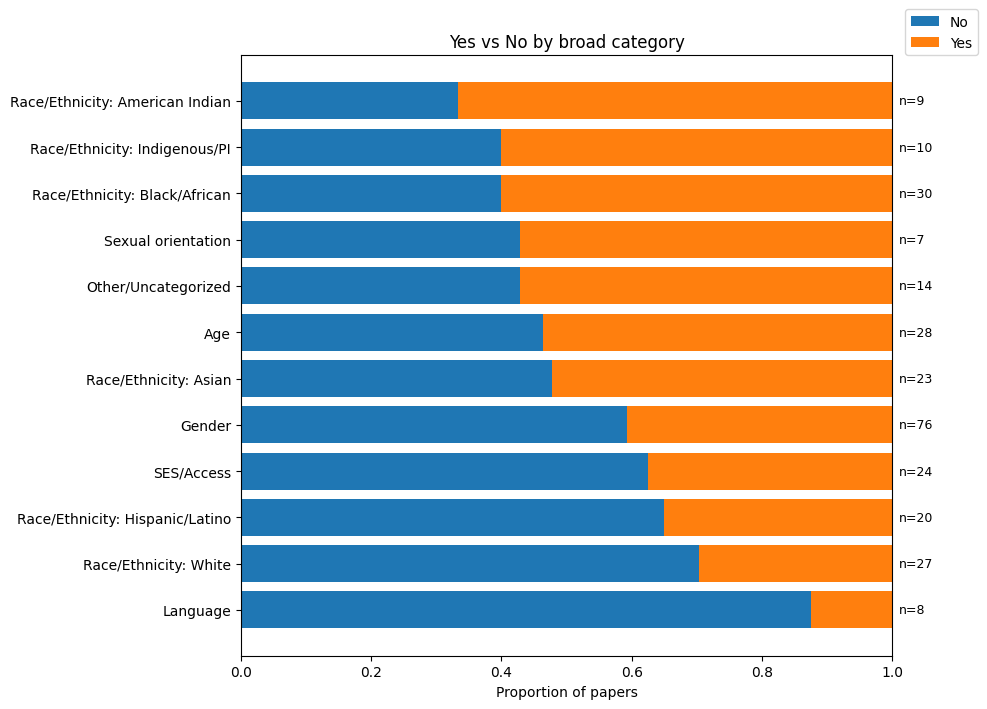

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# build dataframe from merged buckets
plot_df = pd.DataFrame.from_dict(merged, orient="index").fillna(0)
plot_df["total"] = plot_df["yes"] + plot_df["no"]
plot_df = plot_df[plot_df["total"] > 0].copy()

plot_df["yes_pct"] = plot_df["yes"] / plot_df["total"]
plot_df["no_pct"] = plot_df["no"] / plot_df["total"]
plot_df = plot_df.sort_values("yes_pct")

fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(plot_df))))
ax.barh(plot_df.index, plot_df["no_pct"], label="No", )
ax.barh(plot_df.index, plot_df["yes_pct"], left=plot_df["no_pct"], label="Yes")

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of papers")
ax.set_ylabel("")
ax.set_title("Yes vs No by broad category")

# Legend outside the plot area (right side)
ax.legend(loc="lower left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

for i, total in enumerate(plot_df["total"].tolist()):
    ax.text(1.01, i, f"n={int(total)}", va="center", fontsize=9)

plt.tight_layout()
plt.show()